# Confluence マクロ使用状況調査

全スペース・全ページを走査し、使用されているマクロ（`ac:structured-macro`）を集計・可視化します。

**前提**
- `.env` に `CONFLUENCE_DC_URL`, `CONFLUENCE_DC_PAT` を設定済みであること
- `docker compose restart jupyter` で環境変数を反映済みであること

In [1]:
from atlassian import Confluence
from bs4 import BeautifulSoup
from dotenv import load_dotenv
import os
import time
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib  # 日本語フォント設定
%matplotlib inline

load_dotenv()

confluence_url = os.getenv("CONFLUENCE_DC_URL", "http://confluence:8090")
confluence = Confluence(
    url=confluence_url,
    token=os.getenv("CONFLUENCE_DC_PAT"),
)
print(f"接続先: {confluence_url}")

接続先: http://confluence:8090


## 全スペースの取得

In [2]:
all_spaces = []
start = 0
limit = 500

while True:
    result = confluence.get_all_spaces(start=start, limit=limit)
    batch = result.get("results", [])
    if not batch:
        break
    # personal スペースを除外して global スペースのみ対象にする
    all_spaces.extend([s for s in batch if s.get("type") == "global"])
    if len(batch) < limit:
        break
    start += limit

print(f"対象スペース数: {len(all_spaces)}")
for s in all_spaces:
    print(f"  [{s['key']}] {s['name']}")

対象スペース数: 3
  [ds] Demonstration Space
  [KS] KG Space
  [SPC] テスト


## 全ページ走査 + マクロ抽出

各ページのストレージ形式（`body.storage`）から `<ac:structured-macro ac:name="...">` を抽出します。  
ページ数が多い場合は時間がかかります。

In [3]:
records = []  # [{space, page_id, page_title, macro}, ...]
total_pages = 0

for space in all_spaces:
    space_key = space["key"]
    space_name = space["name"]
    page_start = 0
    page_limit = 100
    space_page_count = 0

    while True:
        pages = confluence.get_all_pages_from_space(
            space=space_key,
            start=page_start,
            limit=page_limit,
            expand="body.storage",
        )
        if not pages:
            break

        for page in pages:
            page_id = page["id"]
            page_title = page["title"]
            body = page.get("body", {}).get("storage", {}).get("value", "")

            if body:
                soup = BeautifulSoup(body, "lxml")
                for macro in soup.find_all("ac:structured-macro"):
                    macro_name = macro.get("ac:name")
                    if macro_name:
                        records.append({
                            "space_key": space_key,
                            "space_name": space_name,
                            "page_id": page_id,
                            "page_title": page_title,
                            "macro": macro_name,
                        })

        space_page_count += len(pages)
        if len(pages) < page_limit:
            break
        page_start += page_limit
        time.sleep(0.2)  # レート制限対策

    total_pages += space_page_count
    print(f"[{space_key}] {space_name}: {space_page_count} ページ走査完了")

print(f"\n走査完了: 合計 {total_pages} ページ / {len(records)} マクロ使用箇所")

[ds] Demonstration Space: 10 ページ走査完了
[KS] KG Space: 3 ページ走査完了
[SPC] テスト: 6 ページ走査完了

走査完了: 合計 19 ページ / 13 マクロ使用箇所


## 集計

In [4]:
df = pd.DataFrame(records)

if df.empty:
    print("マクロが検出されませんでした")
else:
    # マクロ名ごとの使用回数
    macro_counts = df["macro"].value_counts().reset_index()
    macro_counts.columns = ["macro", "count"]

    # 使用されているページ数・スペース数を追加
    macro_pages = df.groupby("macro")["page_id"].nunique().reset_index()
    macro_pages.columns = ["macro", "pages"]
    macro_spaces = df.groupby("macro")["space_key"].nunique().reset_index()
    macro_spaces.columns = ["macro", "spaces"]

    macro_counts = macro_counts.merge(macro_pages, on="macro").merge(macro_spaces, on="macro")

    print(f"ユニークなマクロ種類数: {len(macro_counts)}")
    print()
    print("=== マクロ使用状況 TOP 30 ===")
    display(macro_counts.head(30))

ユニークなマクロ種類数: 10

=== マクロ使用状況 TOP 30 ===


,macro,count,pages,spaces
0,widget,2,1,1
1,tip,2,2,2
2,roadmap,2,2,2
3,livesearch,1,1,1
4,info,1,1,1
5,contentbylabel,1,1,1
6,details,1,1,1
7,children,1,1,1
8,panel,1,1,1
9,anchor,1,1,1


## 可視化: マクロ使用頻度 TOP 20

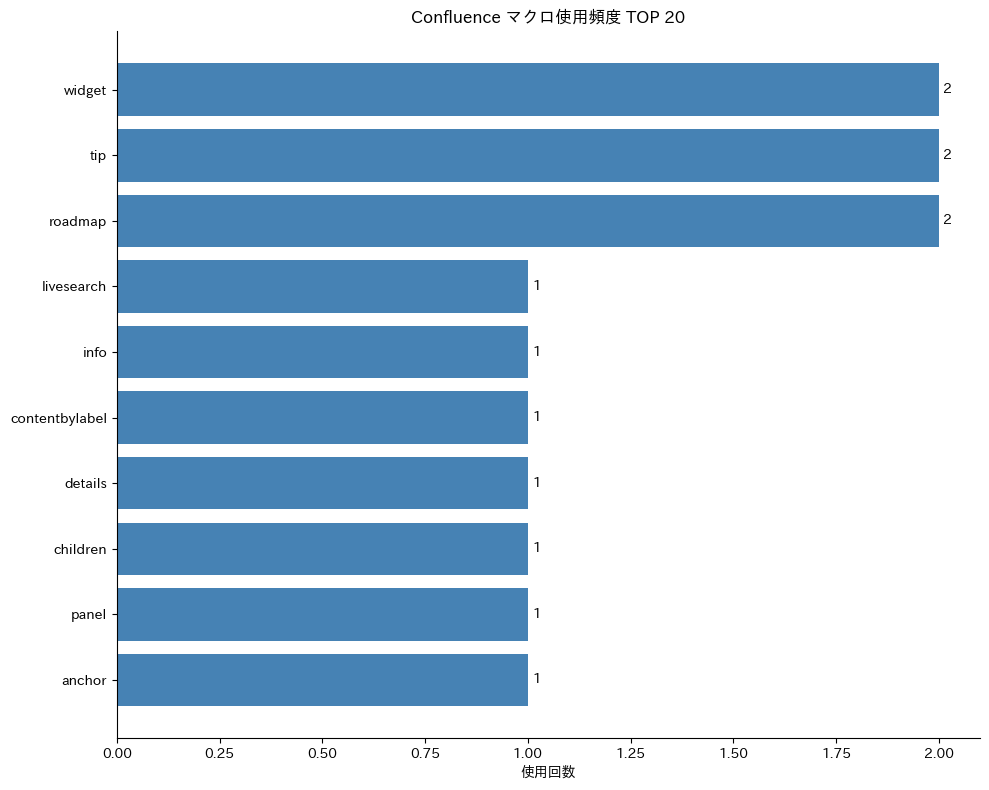

In [5]:
if not df.empty:
    top_n = macro_counts.head(20).iloc[::-1]  # 降順で横棒グラフ

    fig, ax = plt.subplots(figsize=(10, 8))
    bars = ax.barh(top_n["macro"], top_n["count"], color="steelblue")
    ax.bar_label(bars, padding=3)
    ax.set_xlabel("使用回数")
    ax.set_title("Confluence マクロ使用頻度 TOP 20")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

## スペース別マクロ内訳（上位 10 マクロ）

=== スペース別 TOP 10 マクロ使用数 ===


macro,widget,tip,roadmap,livesearch,info,contentbylabel,details,children,panel,anchor
space_key,,,,,,,,,,
KS,0,1,1,1,1,1,1,0,0,0
SPC,0,1,1,0,0,0,0,1,1,1
ds,2,0,0,0,0,0,0,0,0,0


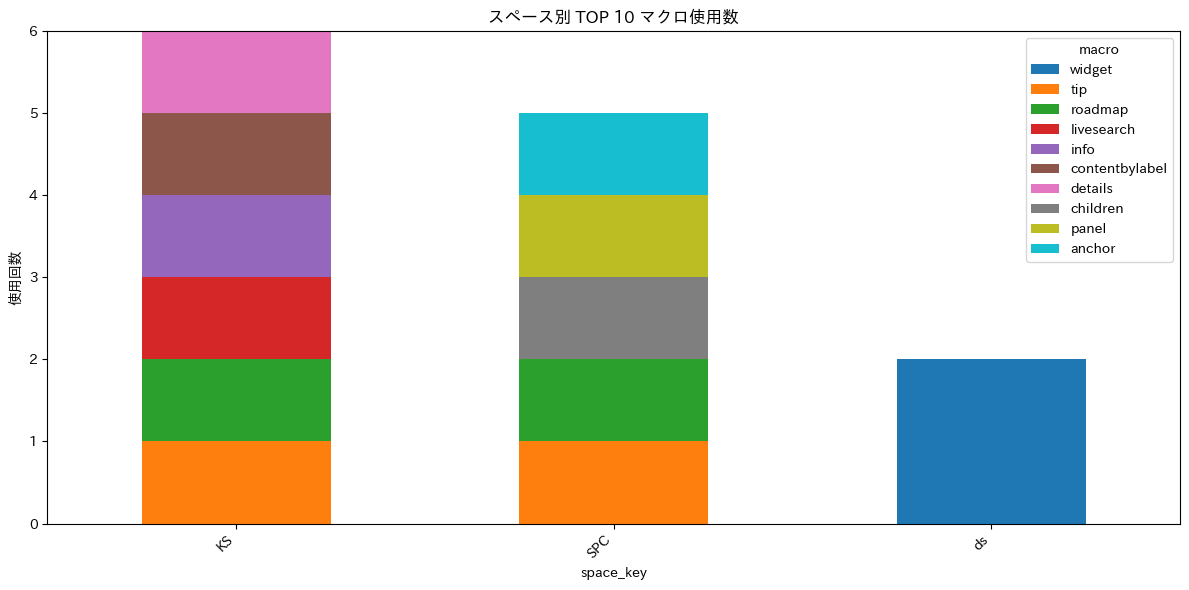

In [6]:
if not df.empty:
    top10_macros = macro_counts.head(10)["macro"].tolist()
    df_top10 = df[df["macro"].isin(top10_macros)]

    pivot = pd.crosstab(df_top10["space_key"], df_top10["macro"])
    # 上位10マクロの順番に並べ替え
    pivot = pivot[[m for m in top10_macros if m in pivot.columns]]

    print("=== スペース別 TOP 10 マクロ使用数 ===")
    display(pivot)

    if len(all_spaces) > 1:
        pivot.plot(
            kind="bar",
            stacked=True,
            figsize=(12, 6),
            title="スペース別 TOP 10 マクロ使用数",
        )
        plt.ylabel("使用回数")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

## CSV エクスポート

In [7]:
if not df.empty:
    df.to_csv("macro_survey_raw.csv", index=False)
    macro_counts.to_csv("macro_survey_summary.csv", index=False)
    print("保存しました:")
    print("  macro_survey_raw.csv     — ページ×マクロの生データ")
    print("  macro_survey_summary.csv — マクロ別集計サマリー")

保存しました:
  macro_survey_raw.csv     — ページ×マクロの生データ
  macro_survey_summary.csv — マクロ別集計サマリー
